In [1]:
import snapatac2 as snap
import scanpy as sc
import numpy as np
import pandas as pd
# Set the environment variable to the desired cache path
import os
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/SpaATAC/GW16'

snap.__version__

'2.6.4'

In [2]:
snapATAC2_obj = sc.read_h5ad("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/GW16/peak_mat.h5ad")
snapATAC2_obj

AnnData object with n_obs × n_vars = 10218 × 187586
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'enhancer_frac', 'promoter_frac', 'tsse_bk', 'doublet_probability', 'doublet_score', 'leiden', 'sample_new', 'cell_name', 'celltype'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [3]:
link_st_matrix = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/link_st_matrix.csv")
link_st_matrix

,id_st,id_rna,cluster_rna
0,GW16:16980_9060,CAATCTAAGTGATTCA-1,ExN_naive
1,GW16:13920_10980,CTCTGTTCAGCGCTTG-1,ExN_immature_2
2,GW16:14460_8220,ACTTACTTCTGTTCAT-1,ExN_naive
3,GW16:15810_11850,GCAGGCAAGAGAAGGG-1,InN_naive
4,GW16:13740_7980,GAGTGTTTCCTAGTCC-1,ExN_immature_1
...,...,...,...
7191,GW16:13230_10080,CTATGGCCAGACAAAC-1,OPC
7192,GW16:13380_9990,AGGCTAGCACGAATTT-1,vIPC
7193,GW16:16950_8730,GAACCTGTCCCTGACT-1,dIPC
7194,GW16:15420_11580,GTATTGTCACGTGCTG-1,OPC


In [4]:
cod = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/spatial_coord.csv", index_col=0)
cod

,cod1,cod2
GW16:14640_7380,14640,7380
GW16:16980_9060,16980,9060
GW16:16530_9420,16530,9420
GW16:13710_8340,13710,8340
GW16:12900_9690,12900,9690
...,...,...
GW16:12840_10560,12840,10560
GW16:14760_12270,14760,12270
GW16:15420_12180,15420,12180
GW16:15810_12090,15810,12090


In [5]:
id_st_in_cod = set(link_st_matrix['id_st']).intersection(set(cod.index))

In [6]:
len(id_st_in_cod)

7196

In [7]:
obj = snapATAC2_obj[snapATAC2_obj.obs.index.isin(set(link_st_matrix['id_rna']))].copy()
rna_to_st = pd.Series(link_st_matrix['id_st'].values, index=link_st_matrix['id_rna'])
obj.obs['id_st'] = obj.obs.index.map(rna_to_st)
obj.obs['cod1'] = obj.obs['id_st'].map(cod['cod1'])
obj.obs['cod2'] = obj.obs['id_st'].map(cod['cod2'])
obj.obsm['spatial'] = obj.obs[['cod1', 'cod2']].values
obj

AnnData object with n_obs × n_vars = 5182 × 187586
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'enhancer_frac', 'promoter_frac', 'tsse_bk', 'doublet_probability', 'doublet_score', 'leiden', 'sample_new', 'cell_name', 'celltype', 'id_st', 'cod1', 'cod2'
    uns: 'reference_sequences'
    obsm: 'fragment_paired', 'spatial'

In [8]:
obj.obsm['spatial']

array([[15570,  7590],
       [14430, 11640],
       [13470, 10950],
       ...,
       [14640,  7860],
       [14730, 11370],
       [15600,  9180]])

In [9]:
obj.var_names

Index(['chr1:810735-811236', 'chr1:817095-817596', 'chr1:817834-818335',
       'chr1:827302-827803', 'chr1:841083-841584', 'chr1:850285-850786',
       'chr1:857907-858408', 'chr1:858632-859133', 'chr1:867423-867924',
       'chr1:869690-870191',
       ...
       'chrY:19076762-19077263', 'chrY:19566981-19567482',
       'chrY:19567517-19568018', 'chrY:19578510-19579011',
       'chrY:19744467-19744968', 'chrY:19745016-19745517',
       'chrY:19892044-19892545', 'chrY:20549441-20549942',
       'chrY:20558622-20559123', 'chrY:20575413-20575914'],
      dtype='object', length=187586)

In [10]:
obj.obs

,n_fragment,frac_dup,frac_mito,tsse,enhancer_frac,promoter_frac,tsse_bk,doublet_probability,doublet_score,leiden,sample_new,cell_name,celltype,id_st,cod1,cod2
AAACATGCAAAGGCCA-1,6218,0.361995,0.0,16.789909,0.201673,0.318913,16.789909,0.299096,0.006207,1,GW16,InN_ventral_like,InN_ventral_like,GW16:15570_7590,15570,7590
AAACATGCAAGGTCCT-1,4208,0.335544,0.0,9.883450,0.146388,0.367158,9.883450,0.351918,0.001206,15,GW16,ExN_major_immture,ExN_immature_1,GW16:14430_11640,14430,11640
AAACATGCAAGTGTTT-1,5720,0.347404,0.0,21.818182,0.187413,0.445280,21.818182,0.348285,0.001516,2,GW16,dorsal_glia,dorsal_glia,GW16:13470_10950,13470,10950
AAACATGCACTAAGTT-1,7818,0.348174,0.0,14.125317,0.178818,0.300333,14.125317,0.299096,0.006207,9,GW16,MFOL,MFOL,GW16:13050_9750,13050,9750
AAACATGCAGTCTAGC-1,7319,0.329148,0.0,9.250399,0.146468,0.223801,9.250399,0.337463,0.002463,15,GW16,ExN_major_immture,ExN_immature_1,GW16:15990_10020,15990,10020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCGCTAGTG-1,4112,0.357199,0.0,12.883805,0.155642,0.335603,12.883805,0.309317,0.005141,10,GW16,ExN_CCK+_immature,ExN_immature_2,GW16:16230_9570,16230,9570
TTTGTTGGTAATGGCC-1,6146,0.344357,0.0,21.544929,0.178490,0.335665,21.544929,0.260644,0.010851,5,GW16,ExN_major,ExN_mature_1,GW16:14700_8370,14700,8370
TTTGTTGGTGTTTGTC-1,7497,0.339820,0.0,15.085351,0.171269,0.278111,15.085351,0.248873,0.012549,5,GW16,ExN_major,ExN_mature_1,GW16:14640_7860,14640,7860
TTTGTTGGTTCGGTAA-1,5585,0.344330,0.0,17.021277,0.169919,0.408774,17.021277,0.359218,0.000597,2,GW16,dorsal_glia,dorsal_glia,GW16:14730_11370,14730,11370


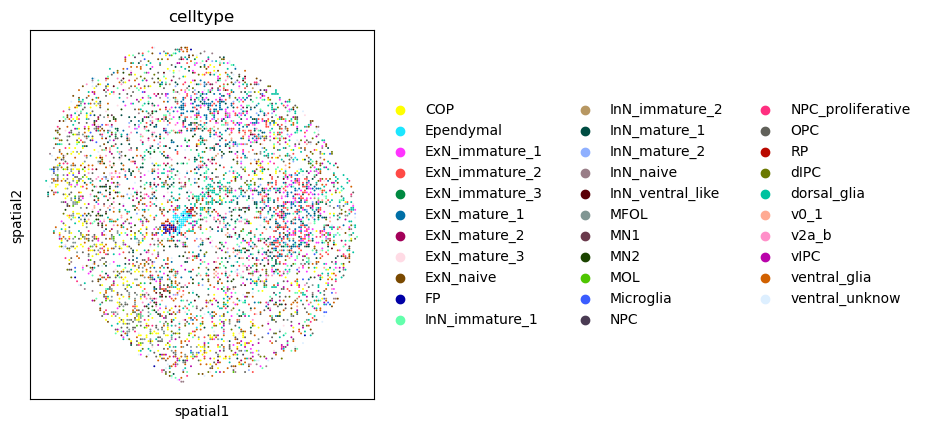

In [11]:
sc.pl.spatial(obj, basis='spatial', spot_size=30, color=['celltype'])

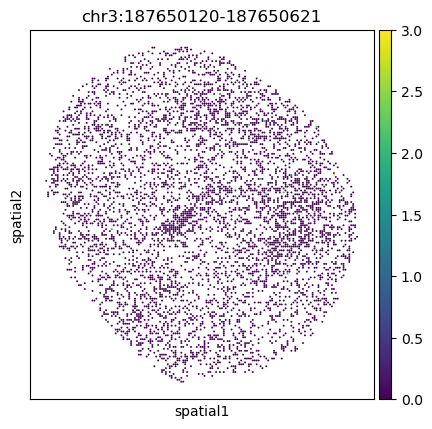

In [12]:
sc.pl.spatial(obj, basis='spatial', spot_size=30, color=['chr3:187650120-187650621'], vmax=3)

In [54]:
# Load data
adata = sc.read_h5ad("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/Smooth/H5AD/SeuratObj_gw16.h5ad")
adata.obsm['spatial'] = adata.obsm['X_cod']

# Define center coordinates
center_x = 14520
center_y = 9810

# Rotate coordinates
# Define the current axis angle
current_axis_angle = 303  # Key parameter

# Compute rotation angle (to make the axis vertically upward)
rotation_angle = -current_axis_angle  # Negative sign indicates clockwise rotation

# Convert to radians
theta = np.radians(rotation_angle)

# Get original coordinates
original_coords = adata.obsm['spatial'].copy()

# Center coordinates (shift center point to origin)
centered_coords = original_coords - np.array([center_x, center_y])

# Create rotation matrix
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

# Apply rotation
rotated_coords = np.dot(centered_coords, rotation_matrix)

# Optionally shift back to the original center point
# Here we keep the center point as origin for downstream analysis
final_coords = rotated_coords  # Or add np.array([center_x, center_y]) to shift back

# Save rotated coordinates back to adata
adata.obsm['rotated_spatial'] = final_coords

# Get cell coordinates
cell_coords = adata.obsm['rotated_spatial']

# Compute distance from each cell to the center
distances = np.sqrt((cell_coords[:, 0] - 0)**2 + (cell_coords[:, 1] - 0)**2)

# Compute coordinates relative to center
rel_x = cell_coords[:, 0] - 0
rel_y = cell_coords[:, 1] - 0

# Compute raw angles (radians)
angles_rad = np.arctan2(rel_y, rel_x)

angles_deg = np.degrees(angles_rad)
angles_deg = (angles_deg + 90) % 360
angles_deg = np.where(angles_deg > 180, angles_deg - 360, angles_deg)

# Store computed metrics in adata.obs
adata.obs['distance_to_center'] = distances
adata.obs['angle_to_axis'] = angles_deg


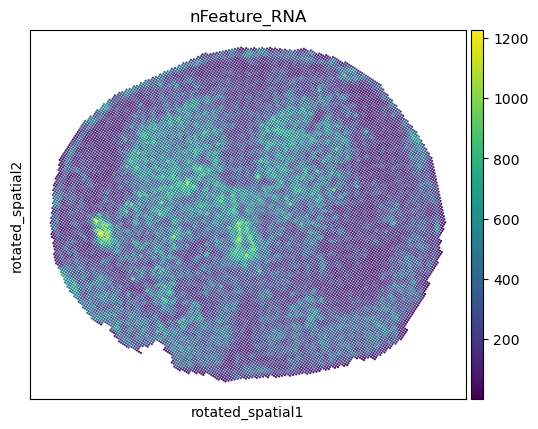

In [55]:
sc.pl.spatial(adata, basis='rotated_spatial', spot_size=30, color=['nFeature_RNA'])

In [ ]:
obj.obs = obj.obs.set_index('id_st')

In [56]:
import anndata
import numpy as np
import pandas as pd
import scipy.sparse

# Step 1: get shared cells
common_cells = set(obj.obs.index) & set(adata.obs.index)
obj_filtered = obj[list(common_cells)].copy()

# Step 2: find cells only present in adata
only_in_filtered = set(adata.obs.index) - set(obj.obs.index)
num_new_cells = len(only_in_filtered)
num_genes = obj.shape[1]  # Number of genes

# Step 3: create a zero-expression matrix (keep sparse format)
if num_new_cells > 0:
    # Create sparse zero matrix
    zeros_matrix = scipy.sparse.csr_matrix((num_new_cells, num_genes), dtype=np.float32)
    
    # Create a new AnnData object
    new_adata = anndata.AnnData(
        X=zeros_matrix,
        obs=adata.obs.loc[list(only_in_filtered)].copy(),
        var=obj.var.copy()
    )
    
    # Concatenate two datasets
    combined_adata = anndata.concat([obj_filtered, new_adata], axis=0)
else:
    combined_adata = obj_filtered.copy()

# Ensure obs order matches adata
combined_adata = combined_adata[adata.obs.index].copy()

combined_adata.obs= adata.obs
combined_adata.obsm= adata.obsm

sc.pp.filter_genes(combined_adata, min_cells= 1)
sc.pp.normalize_total(combined_adata)
sc.pp.log1p(combined_adata)
sc.external.pp.magic(combined_adata, solver="approximate")

# Filtering criteria: angle within range and distance > 100
angle_mask = (combined_adata.obs['angle_to_axis'] <= -10) & (combined_adata.obs['angle_to_axis'] >= -60)
distance_mask = combined_adata.obs['distance_to_center'] > 100
combined_mask = angle_mask & distance_mask

# Create a new AnnData object with cells passing filters
filtered_adata = combined_adata[combined_mask].copy()

/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:233: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 118927 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/graphtools/base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)


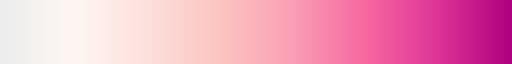

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# Create a gradient colormap
# Define custom color list
custom_colors = ["#EDEDED", "#FFF7F3", "#FDE0DD", "#FCC5C0", "#FA9FB5", 
                 "#F768A1", "#DD3497", "#AE017E"]
custom_cmap = LinearSegmentedColormap.from_list("my_cmap", custom_colors, N=256)
custom_cmap

In [60]:
import pyranges as pr
pr_consensus_bed = pr.read_bed('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/GW16/outs/consensus_peaks.bed')
pr_region = pr.PyRanges(chromosomes=['chr3'], starts=['187568912'], ends=['187770394'])
consensus_bed_region_intersect = pr_consensus_bed.intersect(pr_region)
consensus_bed_region_intersect

,Chromosome,Start,End
0,chr3,187574291,187574792
1,chr3,187590810,187591311
2,chr3,187610590,187611091
3,chr3,187612038,187612539
4,chr3,187629623,187630124
5,chr3,187641430,187641931
6,chr3,187650120,187650621
7,chr3,187666016,187666517
8,chr3,187670184,187670685
9,chr3,187675395,187675896


In [61]:
# Create loci list from a PyRanges object
loci_list = [f"{row.Chromosome}:{row.Start}-{row.End}" 
             for row in consensus_bed_region_intersect.df.itertuples()]

# Create corresponding title list
titles = [f"E{i}, {loci}" for i, loci in enumerate(loci_list)]

valid_indices = [i for i, loci in enumerate(loci_list) 
                if loci in filtered_adata.var_names or loci in filtered_adata.obs.columns]

valid_loci = [loci_list[i] for i in valid_indices]
valid_titles = [titles[i] for i in valid_indices]

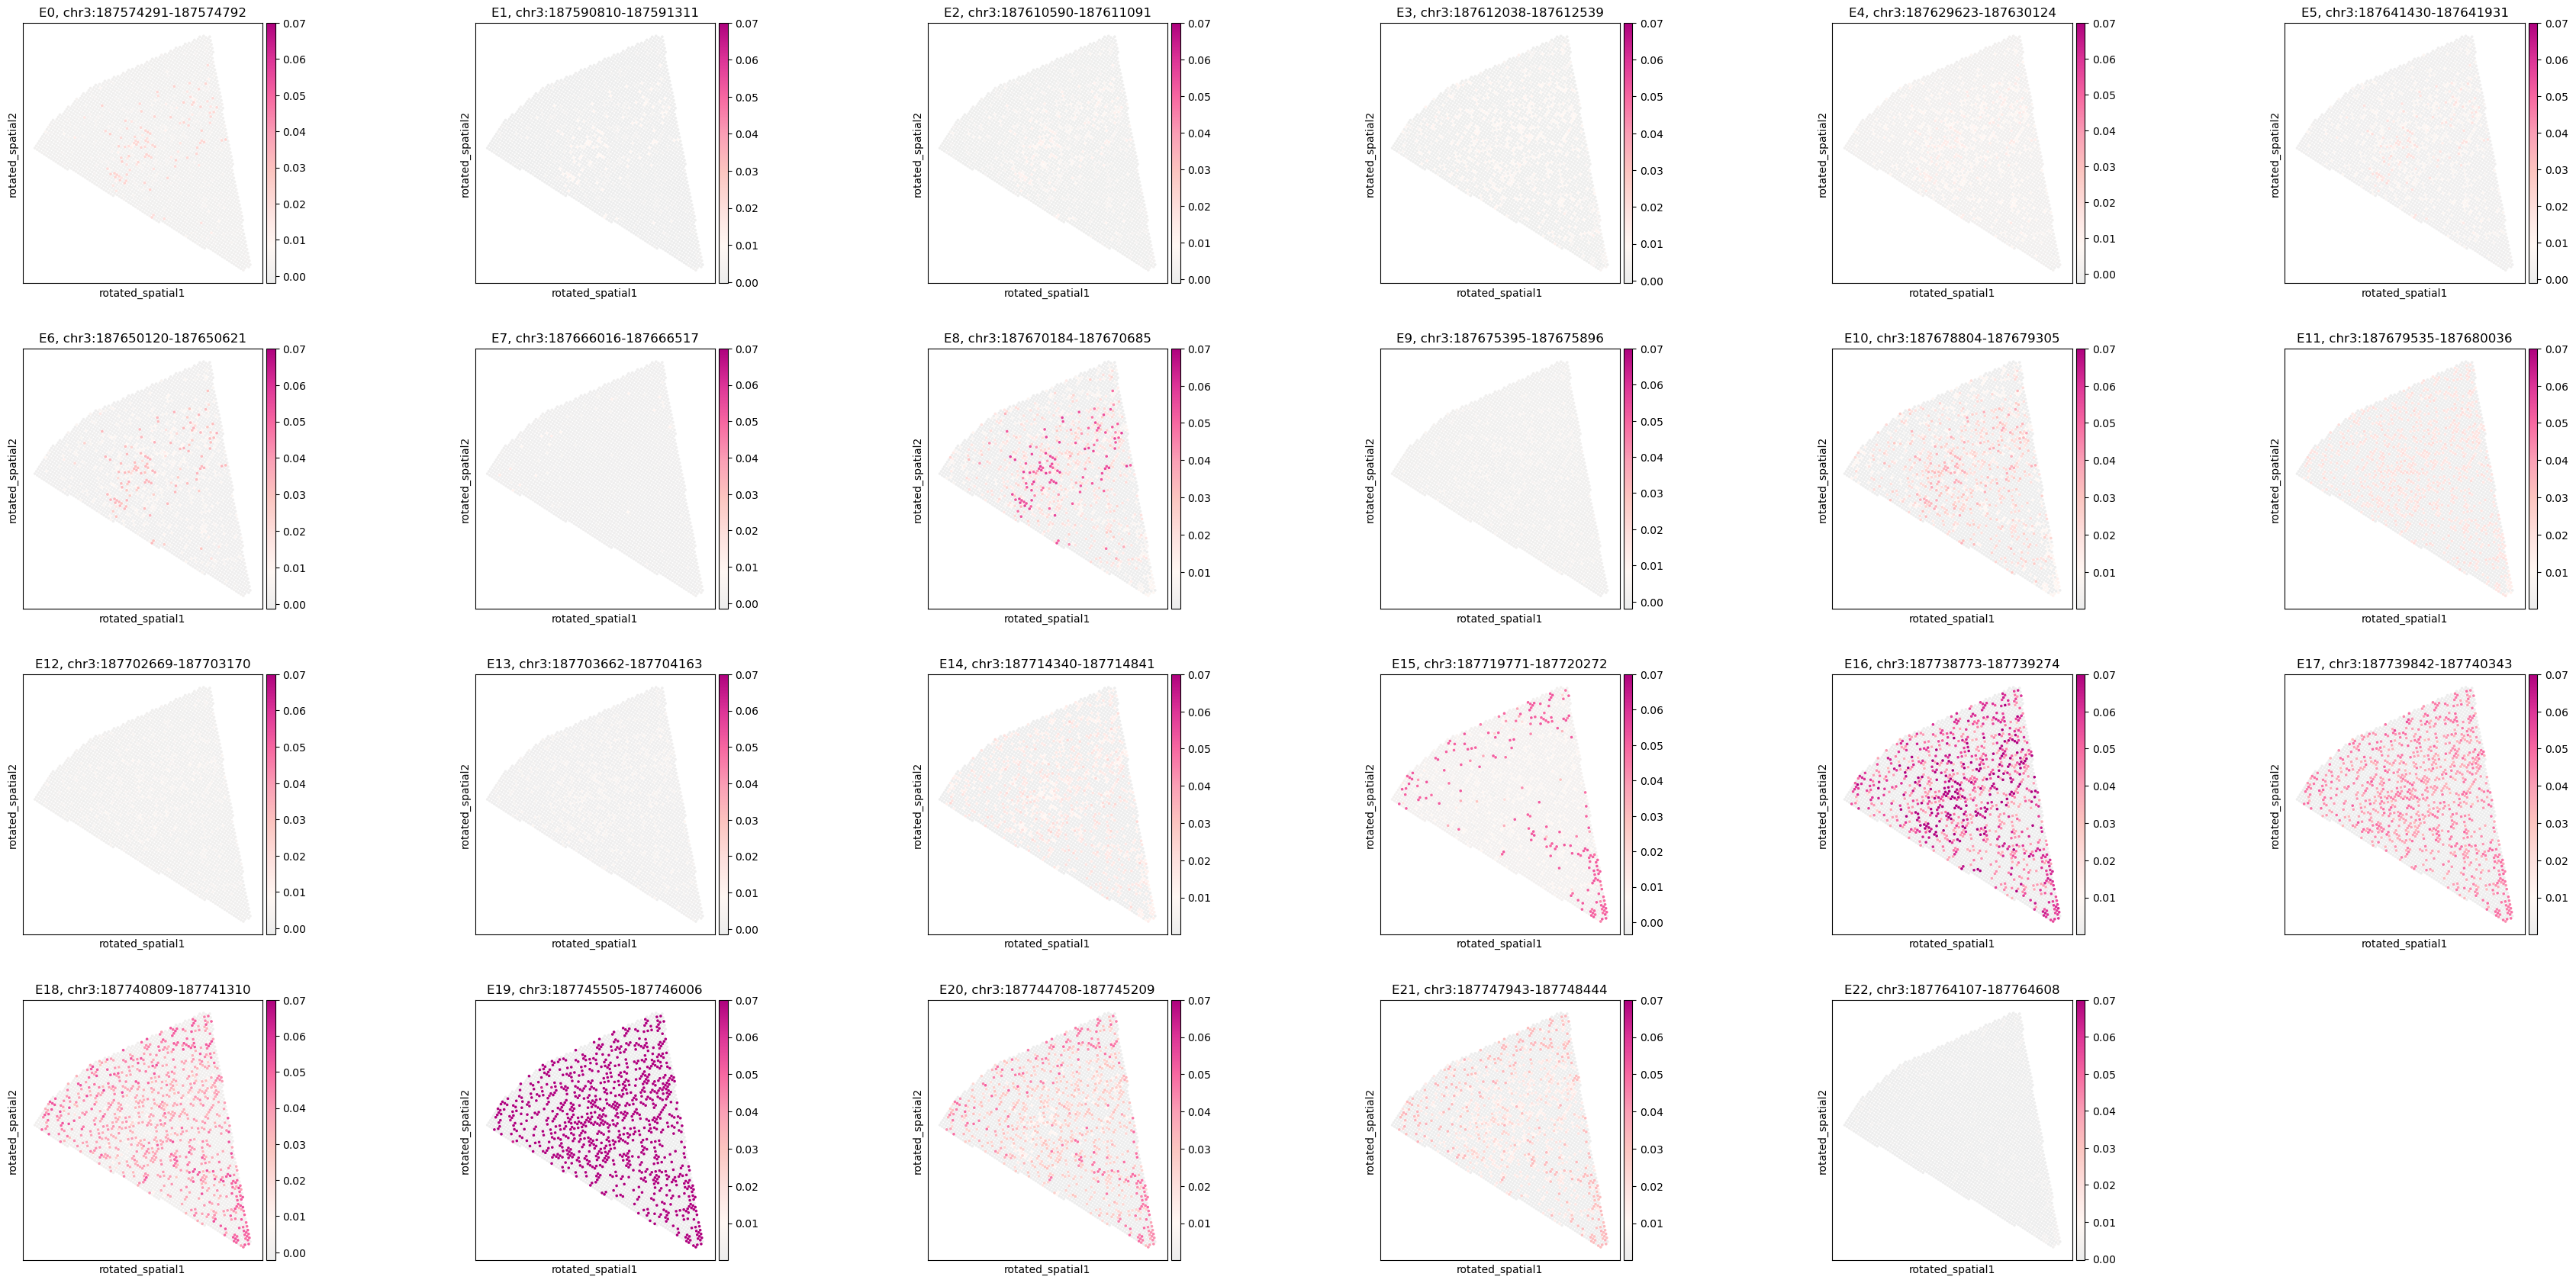

In [63]:
sc.pl.spatial(filtered_adata, 
              basis='rotated_spatial', 
              cmap= custom_cmap, 
              use_raw=False, 
              spot_size=30, 
              color=valid_loci, 
              title=valid_titles,
              ncols=6,
              # show=False,
              save='GW16_SST_enhancers.pdf',
              vmax=.07)

# TF deviation mapping

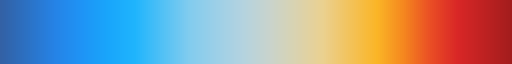

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# Gradient colormap
tf_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
tf_cmap = LinearSegmentedColormap.from_list("my_cmap", tf_colors, N=256)
tf_cmap


In [4]:
chromvar = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/chromvar_cisbp.h5ad')
chromvar

AnnData object with n_obs × n_vars = 9282 × 1141

In [5]:
link_st_matrix = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/link_st_matrix.csv")
cod = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/spatial_coord.csv", index_col=0)
id_st_in_cod = set(link_st_matrix['id_st']).intersection(set(cod.index))
len(id_st_in_cod)

7196

In [6]:
chromvar.obs.index

Index(['GW16_AAACAGCCACCTCAGG-1', 'GW16_AAACAGCCAGGATGGC-1',
       'GW16_AAACATGCAATAACCT-1', 'GW16_AAACATGCACTAAGTT-1',
       'GW16_AAACCGAAGAACAAGT-1', 'GW16_AAACCGAAGCACTTGG-1',
       'GW16_AAACCGAAGCAGGTTT-1', 'GW16_AAACCGAAGGTTTGAC-1',
       'GW16_AAACCGCGTGATCAGC-1', 'GW16_AAACCGGCAACAACAA-1',
       ...
       'GW20_TTTGTCCCACGTGCTG-1', 'GW20_TTTGTCTAGAGGGACT-1',
       'GW20_TTTGTCTAGGTCCAAT-1', 'GW20_TTTGTGAAGCGCCTAA-1',
       'GW20_TTTGTGGCAAGATTCT-1', 'GW20_TTTGTGGCAAGTCGCT-1',
       'GW20_TTTGTGGCACGTAATT-1', 'GW20_TTTGTGTTCCGCATGA-1',
       'GW20_TTTGTTGGTCACAAAT-1', 'GW20_TTTGTTGGTTTGAGGC-1'],
      dtype='object', length=9282)

In [11]:
link_st_matrix['sample_id_rna'] = 'GW16_' + link_st_matrix['id_rna']
obj = chromvar[chromvar.obs.index.isin(set(link_st_matrix['sample_id_rna']))].copy()
rna_to_st = pd.Series(link_st_matrix['id_st'].values, index=link_st_matrix['sample_id_rna'])
obj.obs['id_st'] = obj.obs.index.map(rna_to_st)
obj.obs['cod1'] = obj.obs['id_st'].map(cod['cod1'])
obj.obs['cod2'] = obj.obs['id_st'].map(cod['cod2'])
obj.obsm['spatial'] = obj.obs[['cod1', 'cod2']].values
obj

AnnData object with n_obs × n_vars = 1442 × 1141
    obs: 'id_st', 'cod1', 'cod2'
    obsm: 'spatial'

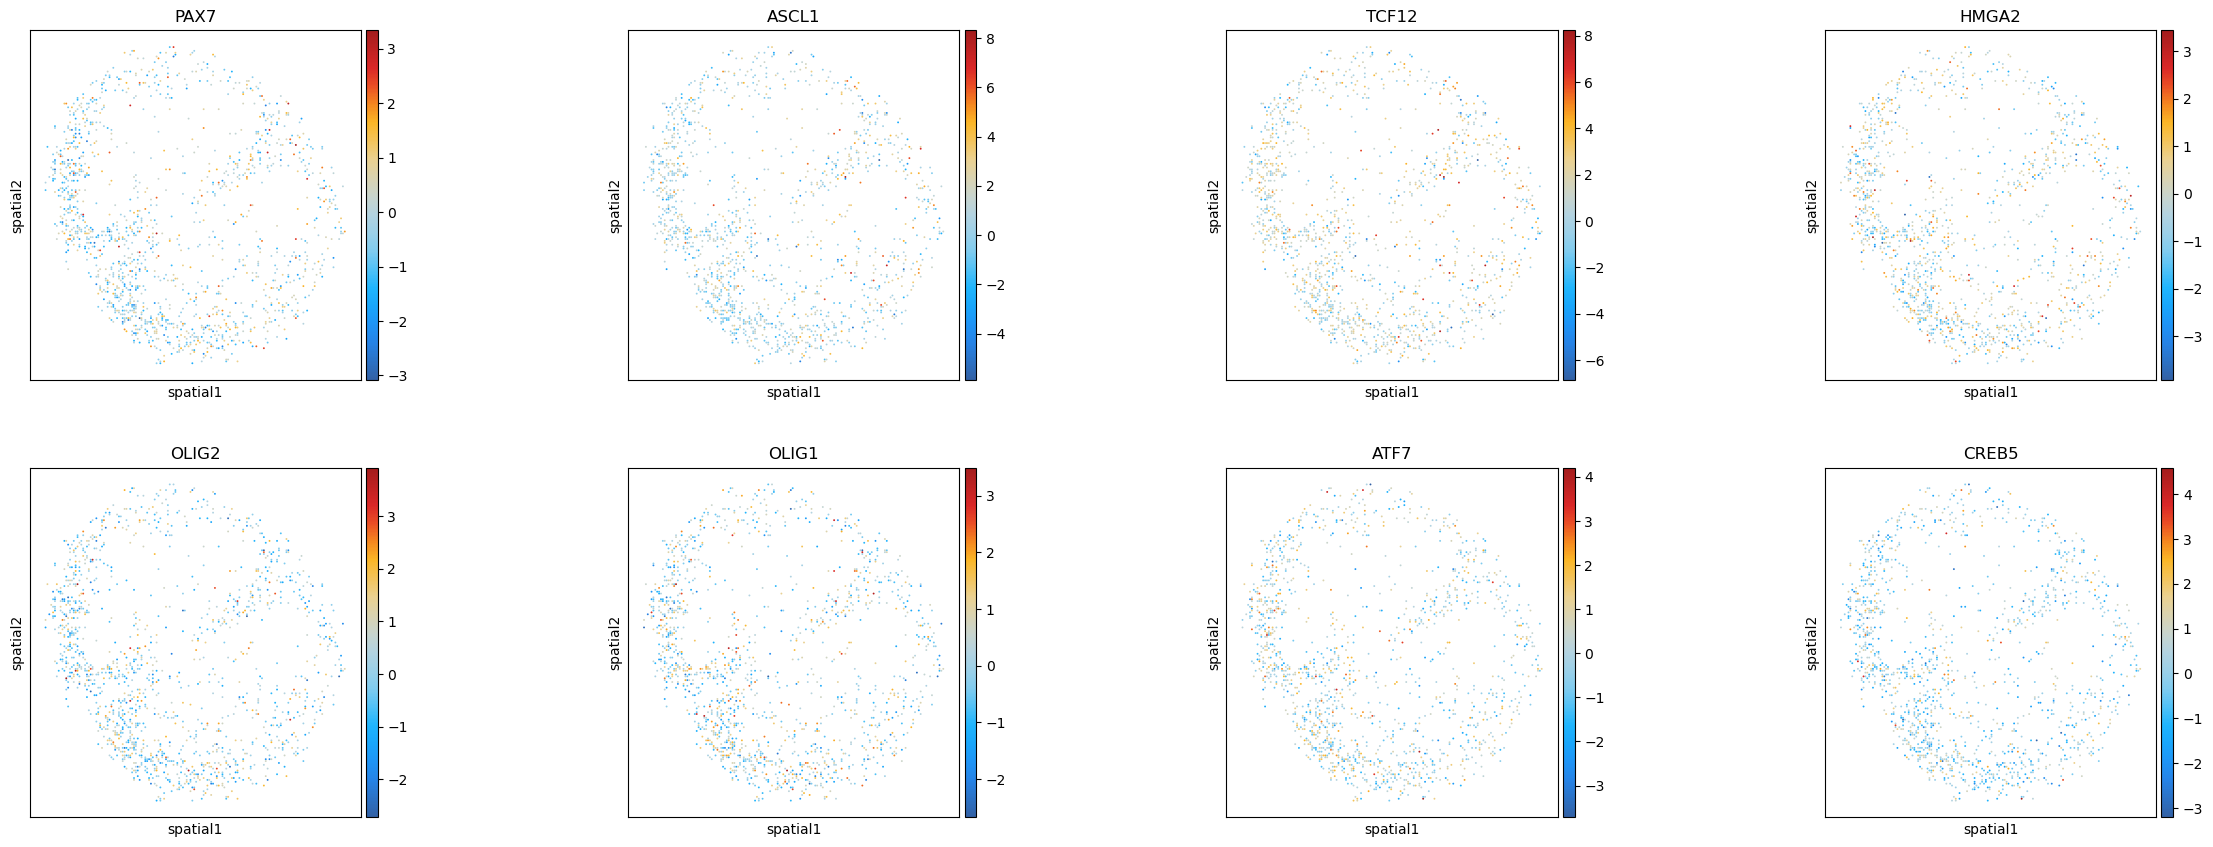

In [ ]:
sc.pl.spatial(obj, 
              basis='spatial', 
              spot_size=30,
              cmap= tf_cmap,
              color=['PAX7', 'ASCL1', 'TCF12', 'HMGA2', 'OLIG2', 'OLIG1', 'ATF7', 'CREB5'])